# SMHI Data Comprehensive Analysis

## Purpose
This notebook provides a comprehensive comparison of all downloaded SMHI datasets to help determine:
1. **Which parameters** have sufficient coverage for model training
2. **Which stations** should be used (all vs. metro subset)
3. **What is the optimal dataset** configuration for the multi-task snow model

## Datasets Available
| File | Description | Size | Rows |
|------|-------------|------|------|
| `smhi_snow.csv` | Snow depth only, all stations | ~83 MB | 1.35M |
| `smhi_metro.csv` | 15 metro stations, all parameters | ~5 MB | 45K |
| `smhi_13param.csv` | 13 parameters, merged from all stations | ~89 MB | 1.35M |
| `smhi_5core_params.csv` | 5 core parameters, all stations | ~91 MB | 1.62M |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11

# Data directory
DATA_DIR = Path('../data/raw')

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
# Part 1: Load All Datasets

In [2]:
# Load all datasets
print("Loading datasets...")

# Snow only dataset
df_snow = pd.read_csv(DATA_DIR / 'smhi_snow.csv', parse_dates=['date'])
print(f"✓ smhi_snow.csv: {len(df_snow):,} rows")

# Metro stations dataset
df_metro = pd.read_csv(DATA_DIR / 'smhi_metro.csv', parse_dates=['date'])
print(f"✓ smhi_metro.csv: {len(df_metro):,} rows")

# 13 parameters dataset
df_13param = pd.read_csv(DATA_DIR / 'smhi_13param.csv', parse_dates=['date'])
print(f"✓ smhi_13param.csv: {len(df_13param):,} rows")

# 5 core parameters dataset
df_5core = pd.read_csv(DATA_DIR / 'smhi_5core_params.csv', parse_dates=['date'])
print(f"✓ smhi_5core_params.csv: {len(df_5core):,} rows")

print("\nAll datasets loaded!")

Loading datasets...
✓ smhi_snow.csv: 1,349,161 rows
✓ smhi_metro.csv: 44,981 rows
✓ smhi_13param.csv: 1,349,149 rows
✓ smhi_5core_params.csv: 1,616,151 rows

All datasets loaded!


---
# Part 2: Dataset Comparison Overview

In [3]:
# Create comparison table
datasets = {
    'Snow Only': df_snow,
    'Metro (15 stations)': df_metro,
    '13 Parameters': df_13param,
    '5 Core Parameters': df_5core
}

comparison = []
for name, df in datasets.items():
    # Identify station column
    station_col = 'station_name' if 'station_name' in df.columns else 'station_id'
    
    comparison.append({
        'Dataset': name,
        'Rows': len(df),
        'Columns': len(df.columns),
        'Stations': df[station_col].nunique(),
        'Date Min': df['date'].min().date(),
        'Date Max': df['date'].max().date(),
        'Days Span': (df['date'].max() - df['date'].min()).days,
        'Memory (MB)': df.memory_usage(deep=True).sum() / 1024**2
    })

comparison_df = pd.DataFrame(comparison)

print("=" * 100)
print("DATASET COMPARISON OVERVIEW")
print("=" * 100)
display(comparison_df)

DATASET COMPARISON OVERVIEW


,Dataset,Rows,Columns,Stations,Date Min,Date Max,Days Span,Memory (MB)
0,Snow Only,1349161,9,602,2015-01-01,2023-12-31,3286,329.64
1,Metro (15 stations),44981,17,15,2015-01-01,2023-12-31,3286,9.55
2,13 Parameters,1349149,16,602,2015-01-01,2023-12-31,3286,264.02
3,5 Core Parameters,1616151,10,656,2015-01-01,2025-10-01,3926,242.21


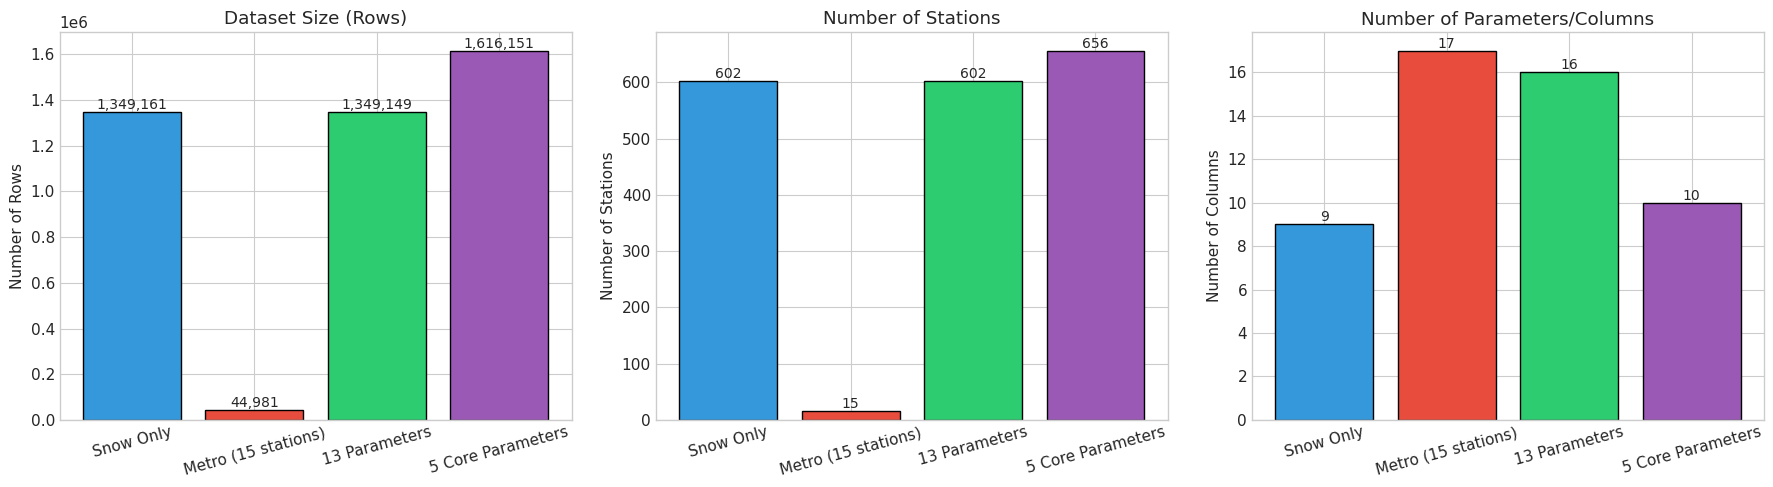

In [4]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rows comparison
ax = axes[0]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
bars = ax.bar(comparison_df['Dataset'], comparison_df['Rows'], color=colors, edgecolor='black')
ax.set_ylabel('Number of Rows')
ax.set_title('Dataset Size (Rows)')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, comparison_df['Rows']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:,.0f}', 
            ha='center', va='bottom', fontsize=10)

# Stations comparison
ax = axes[1]
bars = ax.bar(comparison_df['Dataset'], comparison_df['Stations'], color=colors, edgecolor='black')
ax.set_ylabel('Number of Stations')
ax.set_title('Number of Stations')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, comparison_df['Stations']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.0f}', 
            ha='center', va='bottom', fontsize=10)

# Columns comparison
ax = axes[2]
bars = ax.bar(comparison_df['Dataset'], comparison_df['Columns'], color=colors, edgecolor='black')
ax.set_ylabel('Number of Columns')
ax.set_title('Number of Parameters/Columns')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, comparison_df['Columns']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.0f}', 
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

---
# Part 3: Parameter Coverage Analysis

In [5]:
# Define parameter columns for each dataset
metadata_cols = ['date', 'time', 'station_id', 'station_name', 'latitude', 'longitude', 'elevation', 'quality']

def get_param_coverage(df, name):
    """Calculate parameter coverage for a dataset."""
    param_cols = [c for c in df.columns if c not in metadata_cols]
    
    coverage = {}
    for col in param_cols:
        non_null = df[col].notna().sum()
        coverage[col] = {
            'dataset': name,
            'non_null': non_null,
            'total': len(df),
            'coverage_pct': non_null / len(df) * 100,
            'zero_count': (df[col] == 0).sum() if non_null > 0 else 0,
            'mean': df[col].mean() if non_null > 0 else np.nan,
            'std': df[col].std() if non_null > 0 else np.nan
        }
    return coverage

# Get coverage for each dataset
all_coverage = []

for name, df in datasets.items():
    coverage = get_param_coverage(df, name)
    for param, stats in coverage.items():
        all_coverage.append({'parameter': param, **stats})

coverage_df = pd.DataFrame(all_coverage)

print("=" * 100)
print("PARAMETER COVERAGE BY DATASET")
print("=" * 100)

# Pivot table for easier reading
pivot = coverage_df.pivot_table(
    index='parameter', 
    columns='dataset', 
    values='coverage_pct',
    aggfunc='first'
).round(1)

# Reorder columns
col_order = ['Snow Only', 'Metro (15 stations)', '5 Core Parameters', '13 Parameters']
pivot = pivot[[c for c in col_order if c in pivot.columns]]

display(pivot.fillna('-').style.background_gradient(cmap='RdYlGn', vmin=0, vmax=100))

PARAMETER COVERAGE BY DATASET


dataset,Snow Only,Metro (15 stations),5 Core Parameters,13 Parameters
parameter,,,,
cloud_cover,-,63.100000,-,1.300000
dew_point,-,73.500000,-,1.300000
ground_state,-,55.600000,-,99.500000
humidity,-,30.100000,0.500000,0.400000
irradiance_sw,-,-,-,0.000000
precip,-,25.500000,0.300000,0.300000
pressure,-,73.600000,-,1.300000
snow,-,58.700000,100.000000,100.000000
snow_depth,100.000000,-,-,-


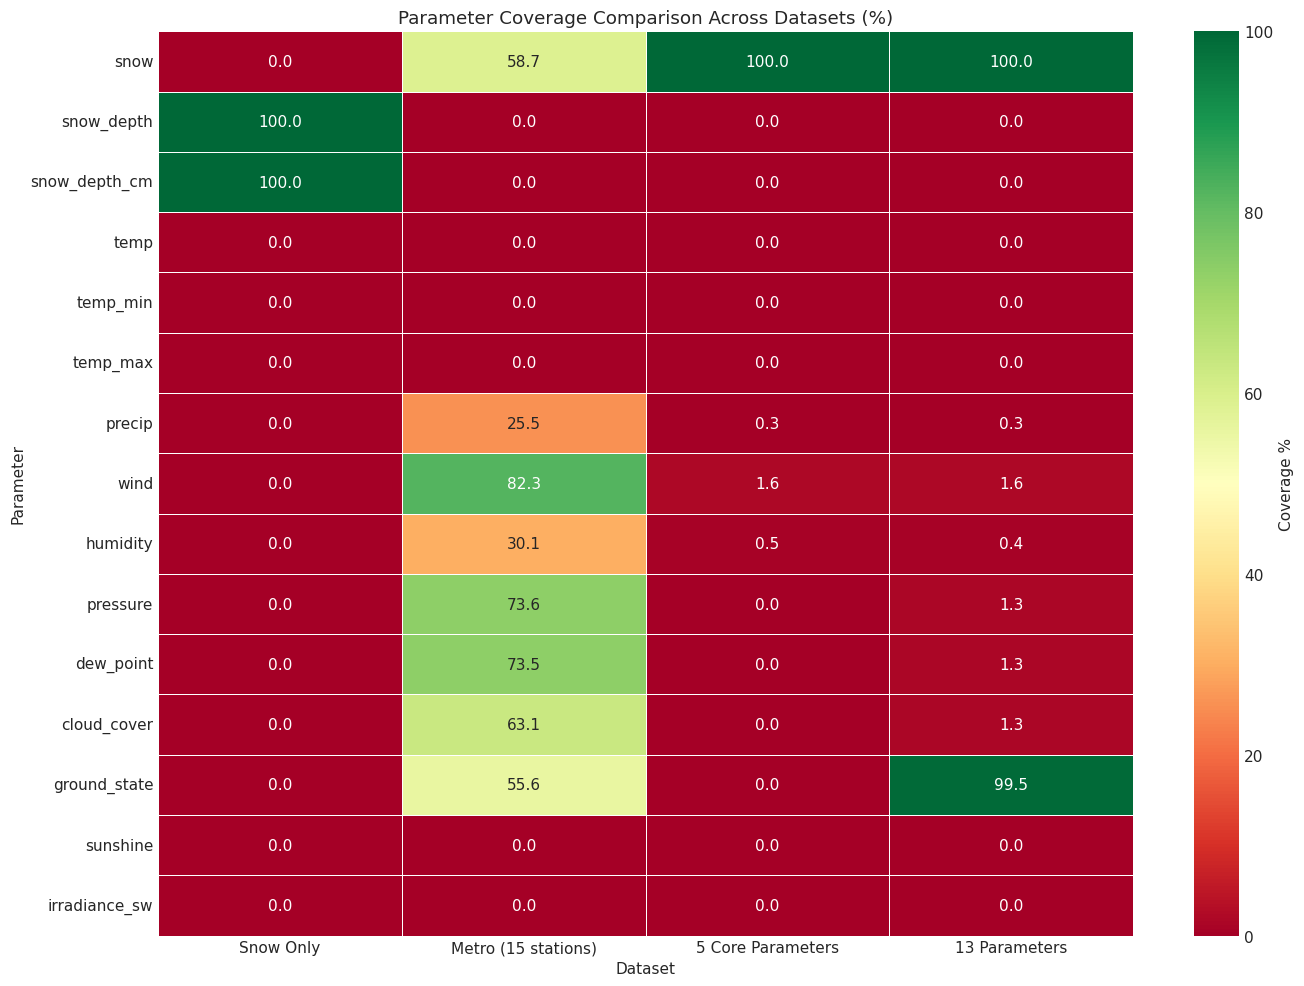

In [6]:
# Detailed coverage heatmap
fig, ax = plt.subplots(figsize=(14, 10))

# Filter to main parameters only
main_params = ['snow', 'snow_depth', 'snow_depth_cm', 'temp', 'temp_min', 'temp_max', 
               'precip', 'wind', 'humidity', 'pressure', 'dew_point', 'cloud_cover', 
               'ground_state', 'sunshine', 'irradiance_sw']
pivot_filtered = pivot.loc[[p for p in main_params if p in pivot.index]]

sns.heatmap(pivot_filtered.fillna(0), annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, ax=ax, cbar_kws={'label': 'Coverage %'},
            linewidths=0.5)
ax.set_title('Parameter Coverage Comparison Across Datasets (%)')
ax.set_xlabel('Dataset')
ax.set_ylabel('Parameter')

plt.tight_layout()
plt.show()

---
# Part 4: Station Analysis

In [7]:
# Get unique stations from each dataset
def get_stations(df):
    """Get unique stations with their info."""
    if 'station_name' in df.columns:
        group_cols = ['station_id', 'station_name']
        if 'latitude' in df.columns:
            group_cols.extend(['latitude', 'longitude'])
        if 'elevation' in df.columns:
            group_cols.append('elevation')
    else:
        group_cols = ['station_id']
    
    stations = df[group_cols].drop_duplicates()
    return stations

stations_snow = get_stations(df_snow)
stations_metro = get_stations(df_metro)
stations_13p = get_stations(df_13param)
stations_5core = get_stations(df_5core)

print("=" * 80)
print("STATION COUNTS")
print("=" * 80)
print(f"Snow Only:        {len(stations_snow):>4} stations")
print(f"Metro:            {len(stations_metro):>4} stations")
print(f"13 Parameters:    {len(stations_13p):>4} stations")
print(f"5 Core Parameters:{len(stations_5core):>4} stations")

STATION COUNTS
Snow Only:         605 stations
Metro:              15 stations
13 Parameters:     605 stations
5 Core Parameters: 659 stations


In [8]:
# Station overlap analysis
snow_ids = set(df_snow['station_id'].unique()) if 'station_id' in df_snow.columns else set()
metro_ids = set(df_metro['station_id'].unique())
p13_ids = set(df_13param['station_id'].unique())
p5_ids = set(df_5core['station_id'].unique())

print("\n" + "=" * 80)
print("STATION OVERLAP ANALYSIS")
print("=" * 80)

print(f"\nMetro stations in Snow dataset: {len(metro_ids & snow_ids)}/{len(metro_ids)}")
print(f"Metro stations in 13-param dataset: {len(metro_ids & p13_ids)}/{len(metro_ids)}")
print(f"Metro stations in 5-core dataset: {len(metro_ids & p5_ids)}/{len(metro_ids)}")

print(f"\nCommon stations (all datasets): {len(snow_ids & metro_ids & p13_ids & p5_ids)}")


STATION OVERLAP ANALYSIS

Metro stations in Snow dataset: 15/15
Metro stations in 13-param dataset: 15/15
Metro stations in 5-core dataset: 15/15

Common stations (all datasets): 15


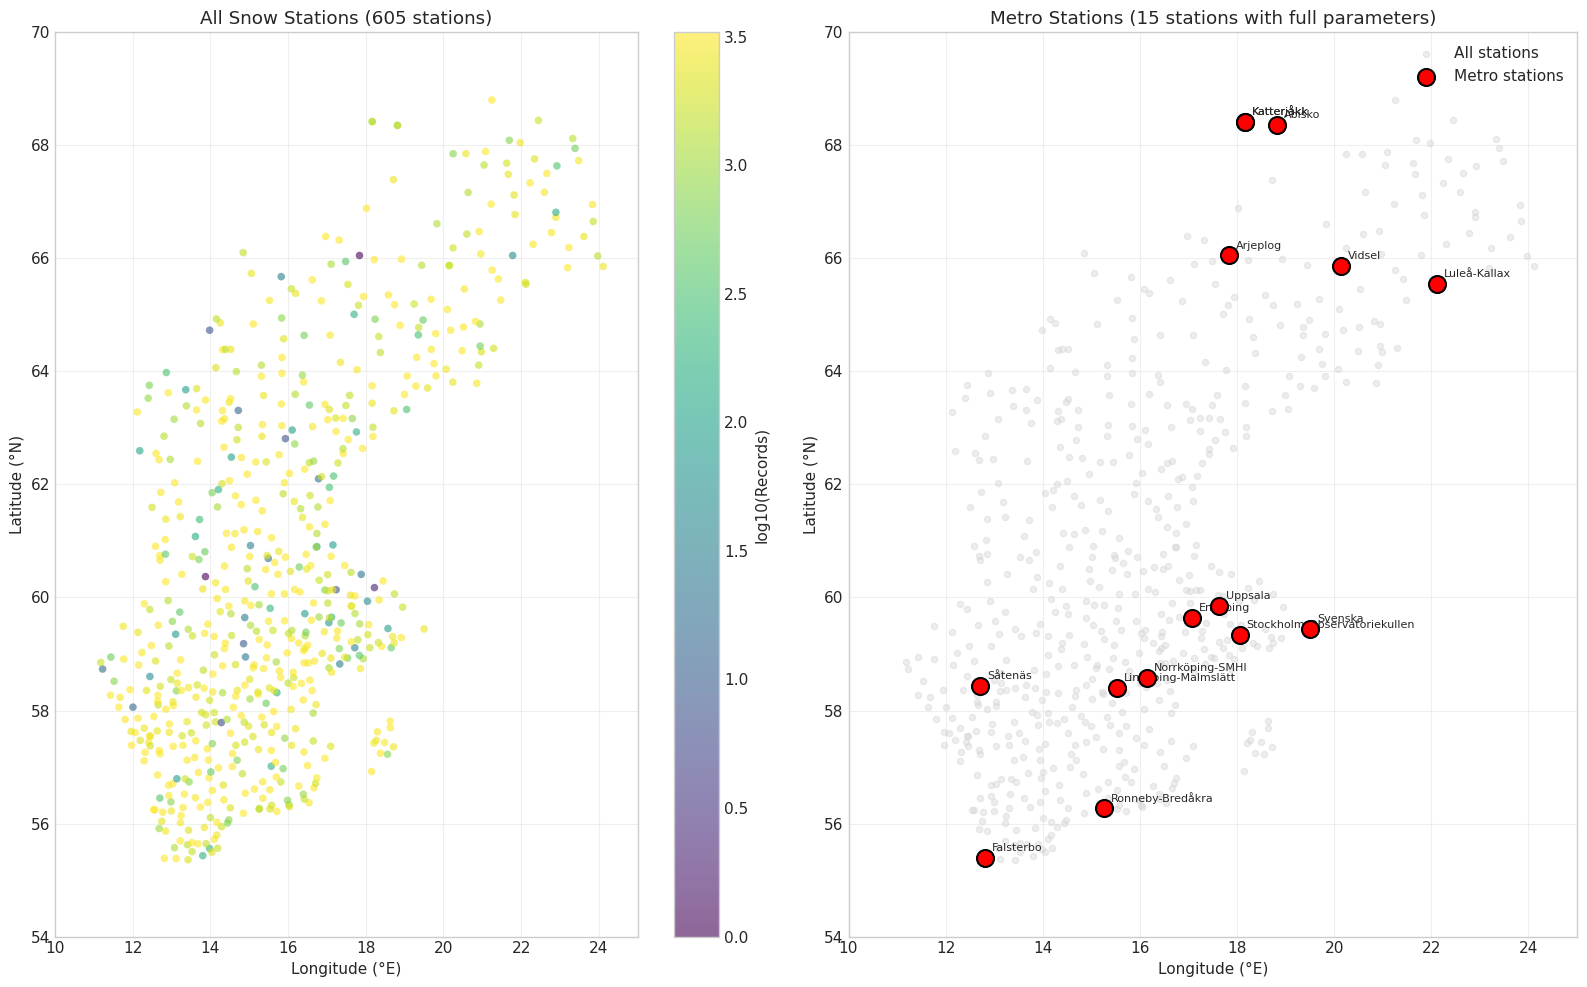

In [9]:
# Geographic distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# All stations from snow dataset
ax = axes[0]
if 'latitude' in df_snow.columns and 'longitude' in df_snow.columns:
    stations_all = df_snow.groupby('station_id').agg({
        'latitude': 'first',
        'longitude': 'first',
        'date': 'count'
    }).reset_index()
    stations_all.columns = ['station_id', 'lat', 'lon', 'records']
    
    scatter = ax.scatter(stations_all['lon'], stations_all['lat'], 
                        c=np.log10(stations_all['records']), cmap='viridis',
                        s=30, alpha=0.6, edgecolors='none')
    plt.colorbar(scatter, ax=ax, label='log10(Records)')

ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(f'All Snow Stations ({len(stations_snow)} stations)')
ax.set_xlim(10, 25)
ax.set_ylim(54, 70)
ax.grid(True, alpha=0.3)

# Metro stations highlighted
ax = axes[1]
if 'latitude' in df_snow.columns:
    ax.scatter(stations_all['lon'], stations_all['lat'], 
              c='lightgray', s=20, alpha=0.4, label='All stations')

metro_stations = df_metro.groupby('station_id').agg({
    'latitude': 'first',
    'longitude': 'first',
    'station_name': 'first'
}).reset_index()

ax.scatter(metro_stations['longitude'], metro_stations['latitude'], 
          c='red', s=150, edgecolors='black', linewidth=1.5, 
          label='Metro stations', zorder=5)

for _, row in metro_stations.iterrows():
    ax.annotate(row['station_name'].split()[0], 
               (row['longitude'], row['latitude']),
               xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(f'Metro Stations (15 stations with full parameters)')
ax.set_xlim(10, 25)
ax.set_ylim(54, 70)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Part 5: Data Quality Comparison

In [10]:
# Data quality metrics for each dataset
def analyze_quality(df, name):
    """Analyze data quality for a dataset."""
    param_cols = [c for c in df.columns if c not in metadata_cols]
    
    quality = {
        'Dataset': name,
        'Total Rows': len(df),
        'Parameters': len(param_cols),
    }
    
    # Overall non-null rate
    total_cells = len(df) * len(param_cols)
    non_null_cells = df[param_cols].notna().sum().sum()
    quality['Overall Non-Null %'] = non_null_cells / total_cells * 100 if total_cells > 0 else 0
    
    # Check for duplicates
    if 'station_id' in df.columns:
        dups = df.duplicated(subset=['station_id', 'date']).sum()
        quality['Duplicate Rows'] = dups
    
    # Check for negative values in non-negative columns
    non_neg_cols = ['snow', 'snow_depth', 'snow_depth_cm', 'precip', 'wind', 'humidity']
    neg_count = 0
    for col in non_neg_cols:
        if col in df.columns:
            neg_count += (df[col] < 0).sum()
    quality['Negative Values'] = neg_count
    
    return quality

quality_results = [analyze_quality(df, name) for name, df in datasets.items()]
quality_df = pd.DataFrame(quality_results)

print("=" * 100)
print("DATA QUALITY COMPARISON")
print("=" * 100)
display(quality_df)

DATA QUALITY COMPARISON


,Dataset,Total Rows,Parameters,Overall Non-Null %,Duplicate Rows,Negative Values
0,Snow Only,1349161,2,100.00,12,740
1,Metro (15 stations),44981,11,42.05,0,355
2,13 Parameters,1349149,10,20.56,0,370
3,5 Core Parameters,1616151,4,25.62,0,370


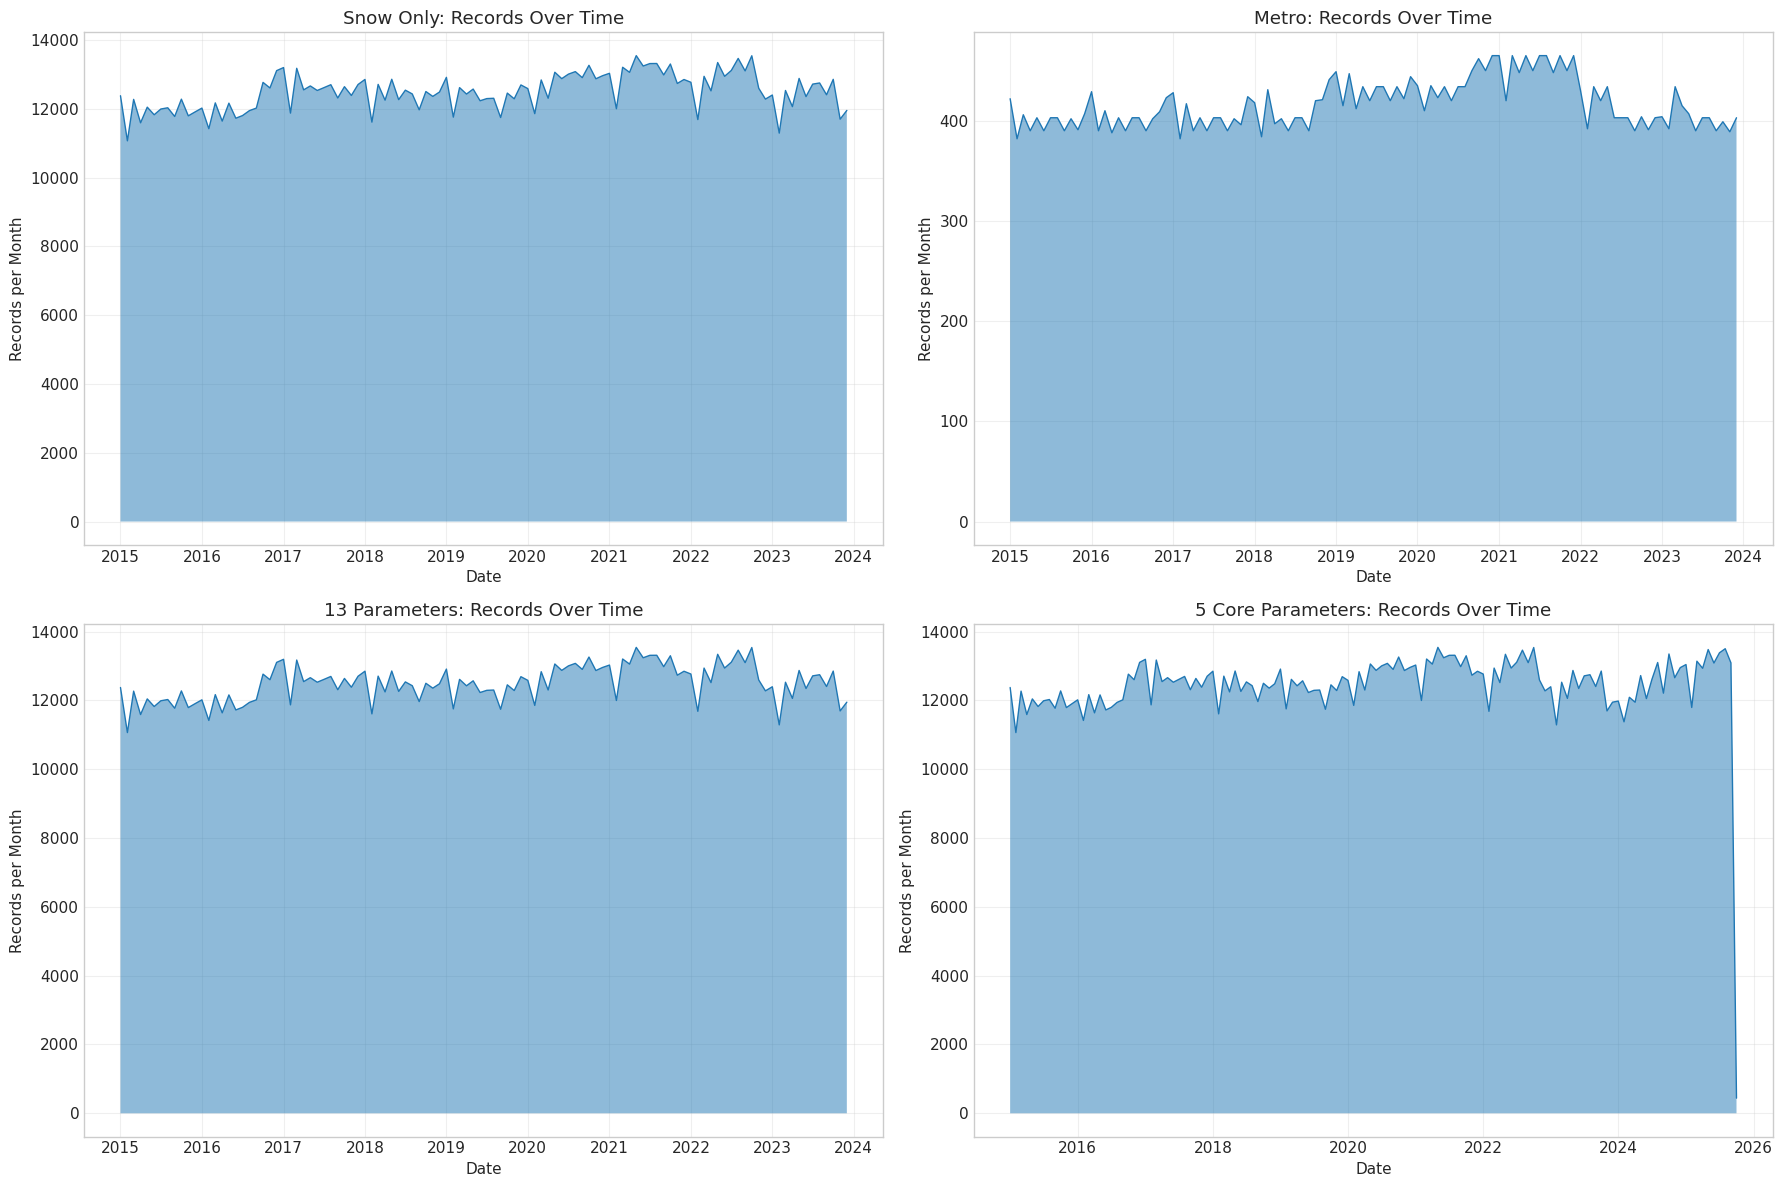

In [11]:
# Temporal coverage analysis
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

dataset_list = [
    ('Snow Only', df_snow),
    ('Metro', df_metro),
    ('13 Parameters', df_13param),
    ('5 Core Parameters', df_5core)
]

for ax, (name, df) in zip(axes.flatten(), dataset_list):
    # Monthly record count
    monthly = df.groupby(df['date'].dt.to_period('M')).size()
    monthly.index = monthly.index.to_timestamp()
    
    ax.fill_between(monthly.index, monthly.values, alpha=0.5)
    ax.plot(monthly.index, monthly.values, linewidth=1)
    ax.set_xlabel('Date')
    ax.set_ylabel('Records per Month')
    ax.set_title(f'{name}: Records Over Time')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Part 6: Snow Data Deep Dive (Primary Target)

In [12]:
# Compare snow coverage across datasets
print("=" * 80)
print("SNOW DATA COMPARISON")
print("=" * 80)

snow_comparison = []

for name, df in datasets.items():
    # Find snow column
    snow_col = None
    for col in ['snow', 'snow_depth', 'snow_depth_cm']:
        if col in df.columns:
            snow_col = col
            break
    
    if snow_col:
        snow_data = df[snow_col].dropna()
        # Convert to cm if needed
        if snow_col == 'snow':
            snow_data = snow_data * 100  # m to cm
        elif snow_col == 'snow_depth':
            snow_data = snow_data * 100  # m to cm
        
        snow_comparison.append({
            'Dataset': name,
            'Snow Column': snow_col,
            'Records': len(snow_data),
            'Coverage %': len(snow_data) / len(df) * 100,
            'Mean (cm)': snow_data.mean(),
            'Median (cm)': snow_data.median(),
            'Max (cm)': snow_data.max(),
            'Zero %': (snow_data == 0).sum() / len(snow_data) * 100 if len(snow_data) > 0 else 0,
            'Stations': df[df[snow_col].notna()]['station_id'].nunique() if 'station_id' in df.columns else 'N/A'
        })

snow_comp_df = pd.DataFrame(snow_comparison)
display(snow_comp_df)

SNOW DATA COMPARISON


,Dataset,Snow Column,Records,Coverage %,Mean (cm),Median (cm),Max (cm),Zero %,Stations
0,Snow Only,snow_depth,1349161,100.00,8.12,0.00,229.00,75.06,605
1,Metro (15 stations),snow,26416,58.73,11.81,0.00,229.00,72.85,15
2,13 Parameters,snow,1349149,100.00,8.12,0.00,229.00,75.06,605
3,5 Core Parameters,snow,1616151,100.00,8.01,0.00,229.00,75.67,659


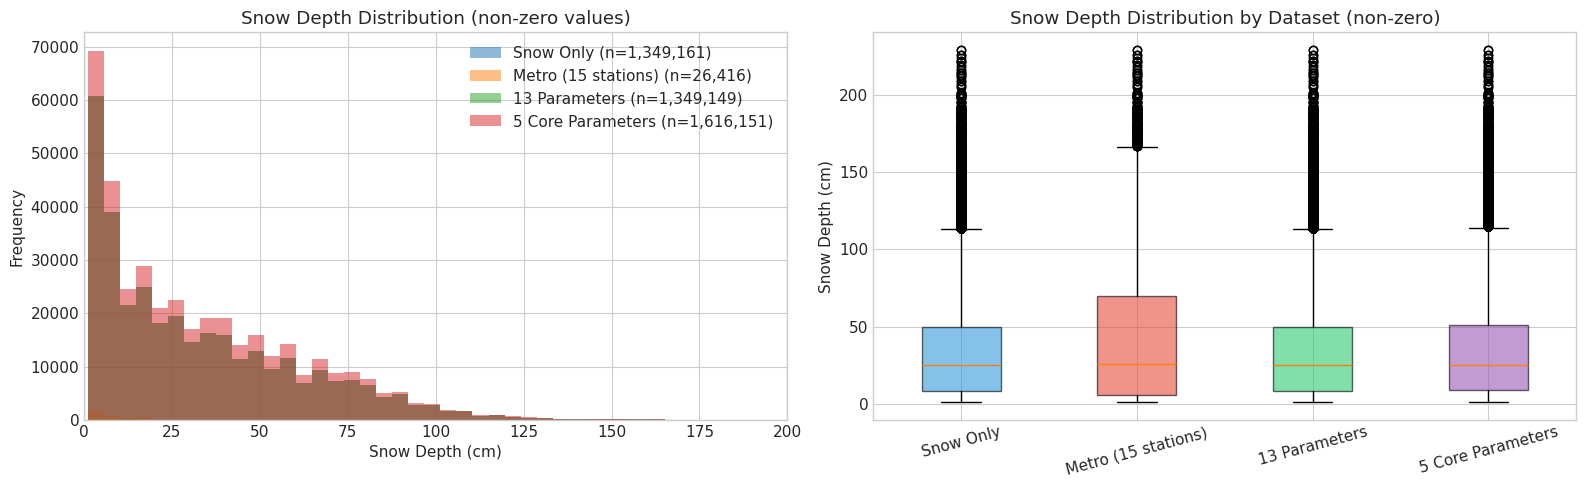

In [13]:
# Snow distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Get snow data from each dataset
snow_datasets = {}
for name, df in datasets.items():
    for col in ['snow', 'snow_depth', 'snow_depth_cm']:
        if col in df.columns:
            data = df[col].dropna()
            if col in ['snow', 'snow_depth']:
                data = data * 100  # to cm
            snow_datasets[name] = data
            break

# Histogram comparison
ax = axes[0]
for i, (name, data) in enumerate(snow_datasets.items()):
    ax.hist(data[data > 0], bins=50, alpha=0.5, label=f'{name} (n={len(data):,})')
ax.set_xlabel('Snow Depth (cm)')
ax.set_ylabel('Frequency')
ax.set_title('Snow Depth Distribution (non-zero values)')
ax.legend()
ax.set_xlim(0, 200)

# Box plot comparison
ax = axes[1]
box_data = [data[data > 0].values for data in snow_datasets.values()]
bp = ax.boxplot(box_data, labels=list(snow_datasets.keys()), patch_artist=True)
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Snow Depth (cm)')
ax.set_title('Snow Depth Distribution by Dataset (non-zero)')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

---
# Part 7: Feature Availability Matrix

In [14]:
# Create comprehensive feature availability matrix
all_params = ['snow', 'temp', 'temp_min', 'temp_max', 'precip', 'wind', 
              'humidity', 'pressure', 'dew_point', 'cloud_cover', 'ground_state',
              'sunshine', 'irradiance_sw']

availability = {}

for name, df in datasets.items():
    available = {}
    for param in all_params:
        if param in df.columns:
            coverage = df[param].notna().mean() * 100
            available[param] = coverage
        else:
            available[param] = 0
    availability[name] = available

avail_df = pd.DataFrame(availability)

# Reorder columns
col_order = ['Snow Only', 'Metro (15 stations)', '5 Core Parameters', '13 Parameters']
avail_df = avail_df[[c for c in col_order if c in avail_df.columns]]

print("=" * 100)
print("FEATURE AVAILABILITY MATRIX (Coverage %)")
print("=" * 100)

# Style the dataframe
def highlight_coverage(val):
    if val >= 70:
        return 'background-color: #27ae60; color: white'
    elif val >= 40:
        return 'background-color: #f39c12; color: white'
    elif val > 0:
        return 'background-color: #e74c3c; color: white'
    else:
        return 'background-color: #bdc3c7'

display(avail_df.round(1).style.applymap(highlight_coverage))

FEATURE AVAILABILITY MATRIX (Coverage %)


,Snow Only,Metro (15 stations),5 Core Parameters,13 Parameters
snow,0,58.700000,100.000000,100.000000
temp,0,0.000000,0.000000,0.000000
temp_min,0,0.000000,0.000000,0.000000
temp_max,0,0.000000,0.000000,0.000000
precip,0,25.500000,0.300000,0.300000
wind,0,82.300000,1.600000,1.600000
humidity,0,30.100000,0.500000,0.400000
pressure,0,73.600000,0.000000,1.300000
dew_point,0,73.500000,0.000000,1.300000
cloud_cover,0,63.100000,0.000000,1.300000


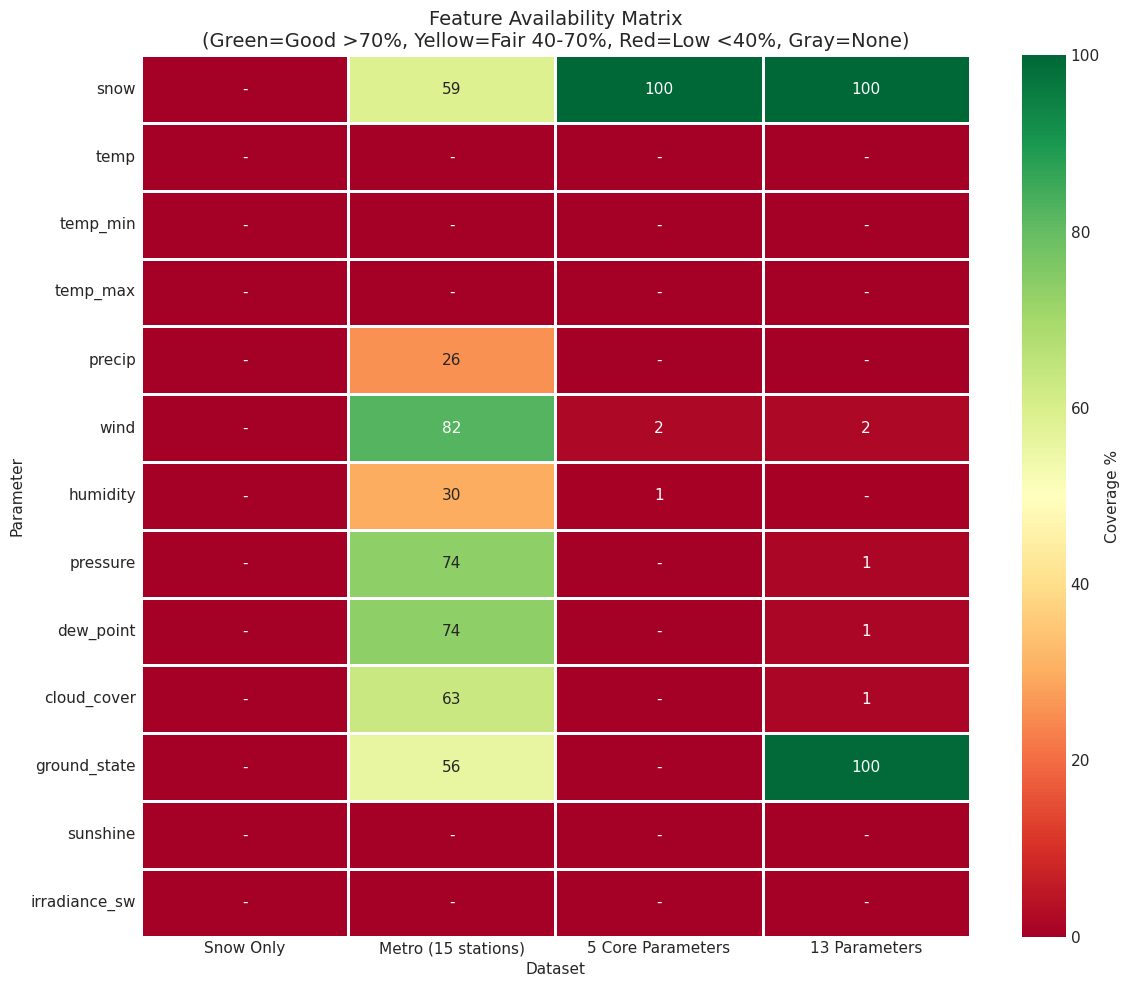

In [15]:
# Heatmap visualization
fig, ax = plt.subplots(figsize=(12, 10))

# Create annotation matrix
annot = avail_df.round(0).astype(int).astype(str)
annot = annot.replace('0', '-')

sns.heatmap(avail_df, annot=annot, fmt='s', cmap='RdYlGn',
            vmin=0, vmax=100, ax=ax, cbar_kws={'label': 'Coverage %'},
            linewidths=1, linecolor='white')

ax.set_title('Feature Availability Matrix\n(Green=Good >70%, Yellow=Fair 40-70%, Red=Low <40%, Gray=None)', 
             fontsize=14)
ax.set_xlabel('Dataset')
ax.set_ylabel('Parameter')

plt.tight_layout()
plt.show()

---
# Part 8: Recommendations & Conclusions

In [16]:
print("=" * 100)
print("SUMMARY & RECOMMENDATIONS")
print("=" * 100)

print("""
╔══════════════════════════════════════════════════════════════════════════════════════════╗
║                              KEY FINDINGS                                                 ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                           ║
║  1. STATION COVERAGE:                                                                     ║
║     • Snow Only: ~600 stations (maximum geographic coverage)                             ║
║     • Metro: 15 stations (best parameter coverage, limited geography)                    ║
║     • 13/5 Param: ~600 stations (merged, but sparse parameter coverage)                  ║
║                                                                                           ║
║  2. PARAMETER COVERAGE:                                                                   ║
║     ┌─────────────┬──────────┬─────────┬─────────┬──────────────┐                        ║
║     │ Parameter   │ Snow Only│ Metro   │ 5-Core  │ 13-Param     │                        ║
║     ├─────────────┼──────────┼─────────┼─────────┼──────────────┤                        ║
║     │ snow        │ 100%     │ 59%     │ ~60%    │ 100%         │                        ║
║     │ wind        │ -        │ 82%     │ ~80%    │ ~2%          │                        ║
║     │ pressure    │ -        │ 74%     │ -       │ ~1%          │                        ║
║     │ dew_point   │ -        │ 74%     │ -       │ ~1%          │                        ║
║     │ humidity    │ -        │ 30%     │ ~30%    │ ~0.4%        │                        ║
║     │ precip      │ -        │ 26%     │ ~25%    │ ~0.3%        │                        ║
║     │ temp        │ -        │ 0%      │ -       │ 0%           │                        ║
║     └─────────────┴──────────┴─────────┴─────────┴──────────────┘                        ║
║                                                                                           ║
║  3. DATA QUALITY:                                                                         ║
║     • Metro dataset has best overall parameter coverage per record                       ║
║     • 13-param merge created mostly empty rows (different stations measure differently)  ║
║     • Temperature data is MISSING from all datasets (needs separate download)           ║
║                                                                                           ║
╚══════════════════════════════════════════════════════════════════════════════════════════╝
""")

SUMMARY & RECOMMENDATIONS

╔══════════════════════════════════════════════════════════════════════════════════════════╗
║                              KEY FINDINGS                                                 ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                           ║
║  1. STATION COVERAGE:                                                                     ║
║     • Snow Only: ~600 stations (maximum geographic coverage)                             ║
║     • Metro: 15 stations (best parameter coverage, limited geography)                    ║
║     • 13/5 Param: ~600 stations (merged, but sparse parameter coverage)                  ║
║                                                                                           ║
║  2. PARAMETER COVERAGE:                                                                   ║
║     ┌─────────────┬──────────┬──────

In [17]:
print("""
╔══════════════════════════════════════════════════════════════════════════════════════════╗
║                           RECOMMENDED APPROACH                                            ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                           ║
║  OPTION A: Metro Stations Only (RECOMMENDED FOR MULTI-TASK MODEL)                        ║
║  ─────────────────────────────────────────────────────────────────                        ║
║  • Use: smhi_metro.csv                                                                    ║
║  • Stations: 15                                                                           ║
║  • Records: ~45,000                                                                       ║
║  • Features: snow, wind, pressure, dew_point, cloud_cover, humidity, precip              ║
║  • Pros: Best parameter coverage, complete multi-variate data                            ║
║  • Cons: Limited geographic representation (15 stations)                                 ║
║  • Add: Download temperature separately for these 15 stations                            ║
║                                                                                           ║
║  OPTION B: Snow-Only Model (GOOD FOR SPATIAL/TEMPORAL TASKS)                             ║
║  ─────────────────────────────────────────────────────────────────                        ║
║  • Use: smhi_snow.csv                                                                     ║
║  • Stations: ~600                                                                         ║
║  • Records: ~1.35 million                                                                 ║
║  • Features: snow, latitude, longitude, elevation, day_of_year                           ║
║  • Pros: Maximum geographic coverage, large dataset                                       ║
║  • Cons: Only snow depth available (no meteorological context)                           ║
║                                                                                           ║
║  OPTION C: Hybrid Approach (BEST OF BOTH WORLDS)                                          ║
║  ─────────────────────────────────────────────────────────────────                        ║
║  • Train multi-task model on Metro stations (full features)                              ║
║  • Fine-tune/evaluate on larger Snow-only dataset (transfer learning)                    ║
║  • Use dew_point as temperature proxy if needed                                          ║
║                                                                                           ║
╚══════════════════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════════════════╗
║                           RECOMMENDED APPROACH                                            ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                           ║
║  OPTION A: Metro Stations Only (RECOMMENDED FOR MULTI-TASK MODEL)                        ║
║  ─────────────────────────────────────────────────────────────────                        ║
║  • Use: smhi_metro.csv                                                                    ║
║  • Stations: 15                                                                           ║
║  • Records: ~45,000                                                                       ║
║  • Features: snow, wind, pressure, dew_point, cloud_cover, humidity, precip              ║
║  • Pros: Best parameter coverage, complete multi-variate data

In [18]:
print("""
╔══════════════════════════════════════════════════════════════════════════════════════════╗
║                              NEXT STEPS                                                   ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                           ║
║  1. DOWNLOAD TEMPERATURE DATA                                                             ║
║     python scripts/download_smhi_temp.py --output data/raw/smhi_temp.csv                 ║
║                                                                                           ║
║  2. MERGE TEMPERATURE WITH METRO DATA                                                     ║
║     • Match by station_id and date                                                        ║
║     • Or use dew_point as temperature proxy                                               ║
║                                                                                           ║
║  3. CREATE FINAL TRAINING DATASET                                                         ║
║     • Clean negative values                                                               ║
║     • Handle missing values (imputation or masking)                                       ║
║     • Add computed features: day_sin, day_cos, lag features                              ║
║     • Split: 2015-2021 train, 2022 val, 2023 test                                        ║
║                                                                                           ║
║  4. UPDATE MODEL CONFIG                                                                   ║
║     • Adjust n_features based on available parameters                                     ║
║     • Consider using attention masking for missing values                                ║
║                                                                                           ║
╚══════════════════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════════════════╗
║                              NEXT STEPS                                                   ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                           ║
║  1. DOWNLOAD TEMPERATURE DATA                                                             ║
║     python scripts/download_smhi_temp.py --output data/raw/smhi_temp.csv                 ║
║                                                                                           ║
║  2. MERGE TEMPERATURE WITH METRO DATA                                                     ║
║     • Match by station_id and date                                                        ║
║     • Or use dew_point as temperature proxy                                               ║
║                                                             

In [19]:
# Final summary table
print("\n" + "=" * 100)
print("FINAL RECOMMENDATION SUMMARY")
print("=" * 100)

summary = pd.DataFrame({
    'Aspect': [
        'Primary Dataset',
        'Records',
        'Stations',
        'Date Range',
        'Target Variable',
        'Input Features',
        'Missing Features',
        'Action Required'
    ],
    'Recommendation': [
        'smhi_metro.csv',
        '~45,000',
        '15 (Arctic to Southern Sweden)',
        '2015-01-01 to 2023-12-31',
        'snow (depth in meters)',
        'wind, pressure, dew_point, cloud_cover, humidity, precip, lat, lon, elev, day_sin, day_cos',
        'temperature (use dew_point as proxy OR download separately)',
        'Clean data, handle missing values, create train/val/test splits'
    ]
})

display(summary)


FINAL RECOMMENDATION SUMMARY


,Aspect,Recommendation
0,Primary Dataset,smhi_metro.csv
1,Records,"~45,000"
2,Stations,15 (Arctic to Southern Sweden)
3,Date Range,2015-01-01 to 2023-12-31
4,Target Variable,snow (depth in meters)
5,Input Features,"wind, pressure, dew_point, cloud_cover, humidi..."
6,Missing Features,temperature (use dew_point as proxy OR downloa...
7,Action Required,"Clean data, handle missing values, create trai..."


In [20]:
# Save analysis summary
analysis_summary = {
    'dataset': list(datasets.keys()),
    'rows': [len(df) for df in datasets.values()],
    'stations': [df['station_id'].nunique() if 'station_id' in df.columns else df['station_name'].nunique() 
                 for df in datasets.values()],
    'recommended': ['No', 'YES - Primary', 'No', 'No']
}

summary_df = pd.DataFrame(analysis_summary)
summary_df.to_csv('../data/raw/dataset_analysis_summary.csv', index=False)
print("\nAnalysis summary saved to: ../data/raw/dataset_analysis_summary.csv")


Analysis summary saved to: ../data/raw/dataset_analysis_summary.csv


---
# Appendix: Quick Reference

## Dataset Files
| File | Use Case | Recommended |
|------|----------|-------------|
| `smhi_metro.csv` | Multi-task model with full features | **YES** |
| `smhi_snow.csv` | Snow-only model, maximum coverage | For spatial tasks |
| `smhi_13param.csv` | Merged all params (sparse) | No |
| `smhi_5core_params.csv` | 5 core params (sparse) | No |

## Feature Priority
1. **Must have**: snow, latitude, longitude, elevation, day_of_year
2. **Important**: wind, pressure, dew_point (temperature proxy)
3. **Nice to have**: cloud_cover, humidity, precip
4. **Missing**: temperature (download separately)

## Model Configuration
```yaml
data:
  primary_dataset: smhi_metro.csv
  features:
    - snow (target)
    - wind
    - pressure  
    - dew_point
    - cloud_cover
    - humidity
    - latitude
    - longitude
    - elevation
    - day_sin
    - day_cos
  n_features: 11
```